# Домашнее задание 1. Знакомство с API
Студент: *Терещенова Лилия*, группа 501, дата 29/03/2026

Задание выполняется в рамках модуля 1 «Проектирование API». Вы закрепите навыки разработки API, используя подход API-first.

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

## Подготовка окружения

### Задание 1. Создать CRUD на основе встроенного HTTP сервера Python

Задача: создать сервер, который будет содержать код API с двумя методами HTTP.

*Здесь мы **специально** берем сильно устаревшую версию веб-сервера, написанную во времена Python 2.0 в 2000 году. Обратите внимание на многословность кода веб-сервера.*


In [ ]:
import pandas as pd
import datetime
import requests
import http.server
import socketserver
import json
import re
import threading
import xml.etree.ElementTree as ET
from dicttoxml import dicttoxml

In [ ]:
df = pd.DataFrame(
    [
        [
            "Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг",
            1025,
            329,
            11,
            "c",
            "антифриз",
            datetime.datetime(2026, 10, 16, 12, 36, 22),
        ],
        [
            "Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг",
            250,
            315,
            38,
            "b",
            "антифриз",
            datetime.datetime(2025, 12, 11, 8, 25, 31),
        ],
        [
            "Антифриз G11 зеленый",
            120,
            329,
            61,
            "b",
            "антифриз",
            datetime.datetime(2025, 6, 15, 15, 36, 30),
        ],
        [
            "Антифриз Antifreeze OEM China OAT red -40 5кг",
            390,
            504,
            65,
            "c",
            "антифриз",
            datetime.datetime(2025, 11, 30, 4, 12, 39),
        ],
        [
            "Антифриз G11 зеленый",
            135,
            407,
            93,
            "b",
            "антифриз",
            datetime.datetime(2026, 8, 25, 3, 24, 1),
        ],
    ]
)

df.columns = [
    "Наименование товара",
    "Цена, руб.",
    "cpm",
    "Скидка",
    "tp",
    "Категория",
    "dt",
]
df["Год"] = df["dt"].dt.year
df = df.drop(["cpm", "tp", "dt"], axis=1)
display(df)

In [ ]:
# --- In-memory database ---
items_db = df.to_dict("index")
next_id = 1


class SimpleCRUDHandler(http.server.BaseHTTPRequestHandler):

    def _send_json_response(self, status_code, data=None):
        self.send_response(status_code)
        self.send_header("Content-type", "application/json")
        self.end_headers()
        if data is not None:
            self.wfile.write(json.dumps(data).encode("utf-8"))

    def _parse_json_body(self):
        content_length = int(self.headers["Content-Length"])
        body = self.rfile.read(content_length)
        try:
            return json.loads(body.decode("utf-8"))
        except json.JSONDecodeError:
            return None

    def do_GET(self):
        global items_db
        match_all = re.match(r"^/items/?$", self.path)
        match_single = re.match(r"^/items/([0-9]+)/?$", self.path)

        if match_all:
            self._send_json_response(200, dict(items_db.items()))
        elif match_single:
            item_id = int(match_single.group(1))
            if int(item_id) in list(items_db.keys()):
                self._send_json_response(200, items_db[item_id])
            else:
                self._send_json_response(404, {"detail": "Item not found"})
        else:
            self._send_json_response(404, {"detail": "Not Found"})

    def do_POST(self):
        global items_db
        match_new = re.match(r"^/items/new/?$", self.path)

        if match_new:
            data = self._parse_json_body()
            if data is not None:
                item_id = len(items_db) + 1
                items_db[item_id] = data
                self._send_json_response(201, {"id": item_id})
            else:
                self._send_json_response(400, {"detail": "Invalid JSON body"})
        else:
            self._send_json_response(404, {"detail": "Not Found"})

    def do_PUT(self):
        global items_db
        item_id = re.match(r"^/items/([0-9]+)/?$", self.path)
        item_id = int(item_id.group(1))

        if item_id:
            data = self._parse_json_body()
            print(data)
            if data is not None:
                items_db[item_id] = data
                self._send_json_response(201, {"id": item_id})
            else:
                self._send_json_response(400, {"detail": "Invalid JSON body"})
        else:
            self._send_json_response(404, {"detail": "Not Found"})

    def do_DELETE(self):
        global items_db
        item_id = re.match(r"^/items/([0-9]+)/?$", self.path)
        item_id = int(item_id.group(1))

        if item_id in items_db.keys():
            items_db.pop(item_id)
            self._send_json_response(201, {"id": item_id})
        else:
            self._send_json_response(404, {"detail": "Not Found"})

In [ ]:
PORT1 = 8000
server1 = socketserver.TCPServer(("127.0.0.1", PORT1), SimpleCRUDHandler)


def run_server1():
    print(f"Serving at port {PORT1} in a separate thread...")
    server1.serve_forever()


server_thread = threading.Thread(target=run_server1)
server_thread.daemon = True
server_thread.start()

print(
    f"Server started on port {PORT1}. Use server_thread.join() to wait for it or stop_server() to stop it."
)

In [ ]:
def stop_server(server):
    print("Stopping server...")
    server.shutdown()
    server.server_close()
    print("Server stopped.")

In [ ]:
# stop_server(server1)

### Задание 2. Подключиться к этому серверу

Подумайте, какие глаголы HTTP нужно использовать для разных методов запроса

```python
import requests
try:
    url = "http://127.0.0.1:8000/items"
    response = requests.get(url)
    print(response.json()[0]['0'])
except Exception as e:
    print(f"Ошибка: {e}")
```

Сервер должен отвечать валидным JSON. Содержание JSONa не важно, главное, чтобы он был валидным.


In [ ]:
try:
    url = "http://127.0.0.1:8000/items/"
    response = requests.get(url)
    print(response.json()["0"])
except Exception as e:
    print(f"Ошибка: {e}")

In [ ]:
# CREATE
try:
    url = "http://127.0.0.1:8000/items/new/"
    len_before = len(items_db.keys())
    response = requests.post(
        url,
        json={
            "Наименование товара": "Антифриз G11 !!зеленый",
            "Цена, руб.": 1025,
            "Скидка": 11,
            "Категория": "антифриз",
            "Год": 2026,
        },
    )
    assert len(items_db.keys()) == len_before + 1
except Exception as e:
    print(f"CREATE Ошибка: {e}")

# READ
try:
    url = "http://127.0.0.1:8000/items/"
    response = requests.get(url)
    assert response.json()["0"] == items_db[0]
except Exception as e:
    print(f"READ Ошибка: {e}")

# UPDATE
try:
    item_id = len(items_db.keys()) - 1
    url = f"http://127.0.0.1:8000/items/{item_id}/"
    response = requests.put(
        url,
        json={
            "Наименование товара": "Антифриз G11 зеленый",
            "Цена, руб.": 1025,
            "Скидка": 11,
            "Категория": "антифриз",
            "Год": 2026,
        },
    )
    assert response.json()["id"] == item_id
except Exception as e:
    print(f"UPDATE Ошибка: {e}")

# # DELETE
try:
    item_id = len(items_db.keys()) - 1
    url = f"http://127.0.0.1:8000/items/{item_id}/"
    response = requests.delete(url)
    assert response.json()["id"] == item_id
except Exception as e:
    print(f"Ошибка: {e}")

### Задание 3. Описать эндпоинты сервера и их методы в формате OpenAPI

Используйте редактор [Swagger](https://editor.swagger.io/), чтобы добавить один проектируемый эндпоинт с ответом в формате **XML**, и сохраните описание в нижеприведенном YAML.

```yaml
openapi: 3.0.3
info:
  title: API для получения товаров
  version: 1.0.0
  description: API для получения товаров из In-memory database

paths:
  /items:
    get:
      operationId: getItems
      summary: Получить все товары
      description: Возвращает объект, где ключ — id товара (как строка), значение — данные товара.
      responses:
        "200":
          description: Успешный ответ
          content:
            application/json:
              schema:
                $ref: "#/components/schemas/ItemsMap"
        "404":
          description: Not Found
          content:
            application/json:
              schema:
                $ref: "#/components/schemas/ErrorResponse"

  /items/{id}/:
    get:
      operationId: getItemById
      summary: Получить товар по id
      parameters:
        - name: id
          in: path
          required: true
          description: Идентификатор товара
          schema:
            type: integer
            minimum: 0
      responses:
        "200":
          description: Товар найден
          content:
            application/json:
              schema:
                $ref: "#/components/schemas/Item"
        "404":
          description: Товар не найден или неверный путь
          content:
            application/json:
              schema:
                $ref: "#/components/schemas/ErrorResponse"

    put:
      operationId: updateItemById
      summary: Обновить товар по id
      parameters:
        - name: id
          in: path
          required: true
          description: Идентификатор товара
          schema:
            type: integer
            minimum: 0
      requestBody:
        required: true
        description: Новые данные товара
        content:
          application/json:
            schema:
              $ref: "#/components/schemas/Item"
      responses:
        "200":
          description: Товар успешно обновлен
          content:
            application/json:
              schema:
                $ref: "#/components/schemas/Item"
        "404":
          description: Товар не найден
          content:
            application/json:
              schema:
                $ref: "#/components/schemas/ErrorResponse"

    delete:
      operationId: deleteItemById
      summary: Удалить товар по id
      parameters:
        - name: id
          in: path
          required: true
          description: Идентификатор товара
          schema:
            type: integer
            minimum: 0
      responses:
        "200":
          description: Товар успешно удален
          content:
            application/json:
              schema:
                $ref: "#/components/schemas/SuccessResponse"
        "404":
          description: Товар не найден
          content:
            application/json:
              schema:
                $ref: "#/components/schemas/ErrorResponse"

components:
  schemas:
    Item:
      type: object
      properties:
        "Наименование товара":
          type: string
          example: "Антифриз G11 зеленый"
        "Цена, руб.":
          type: integer
          example: 1025
        "Скидка":
          type: integer
          example: 11
        "Категория":
          type: string
          example: "антифриз"
        "Год":
          type: integer
          example: 2026
      required:
        - "Наименование товара"
        - "Цена, руб."
        - "Скидка"
        - "Категория"
        - "Год"

    ItemsMap:
      type: object
      additionalProperties:
        $ref: "#/components/schemas/Item"
      example:
        "0":
          "Наименование товара": "Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг"
          "Цена, руб.": 1025
          "Скидка": 11
          "Категория": "антифриз"
          "Год": 2026

    ErrorResponse:
      type: object
      properties:
        detail:
          type: string
          example: "Item not found"
      required:
        - detail

    SuccessResponse:
      type: object
      properties:
        detail:
          type: string
          example: "Item deleted"
      required:
        - detail
```



### Задание 4. Отдавать ответы в формате XML и JSON

Можно попросить один и тот же серверный код отдавать ответы в зависимости от заголовка клиентского запроса

```python
headers = {'Accept': 'application/json'}
response = requests.get(url, headers=headers)
```

или

```python
headers = {'Accept': 'application/xml'}
response = requests.get(url, headers=headers)
```

Пожалуйста, допишите в функции do_GET серверного кода обработку заголовков запроса.


In [ ]:
class JsonXmlCRUDHandler(SimpleCRUDHandler):
    def _send_xml_response(self, status_code, data=None):
        self.send_response(status_code)
        self.send_header("Content-type", "application/xml")
        self.end_headers()
        xml_bytes = dicttoxml(data, custom_root="item", attr_type=False)

        if data is not None:
            self.wfile.write(xml_bytes)

    def do_GET(self):
        global items_db
        match_all = re.match(r"^/items/?$", self.path)
        match_single = re.match(r"^/items/([0-9]+)/?$", self.path)

        if self.headers["Accept"] == "application/xml":
            send_method = self._send_xml_response
        else:
            send_method = self._send_json_response

        if match_all:
            send_method(200, dict(items_db.items()))
        elif match_single:
            item_id = int(match_single.group(1))
            if int(item_id) in list(items_db.keys()):
                send_method(200, items_db[item_id])
            else:
                send_method(404, {"detail": "Item not found"})
        else:
            send_method(404, {"detail": "Not Found"})


def is_valid_json(s: str) -> bool:
    try:
        json.loads(s)
        return True
    except json.JSONDecodeError:
        return False


def is_valid_xml(s: str) -> bool:
    try:
        ET.fromstring(s)
        return True
    except ET.ParseError:
        return False

In [ ]:
PORT2 = 8001
server2 = socketserver.TCPServer(("127.0.0.1", PORT2), JsonXmlCRUDHandler)


def run_server2():
    print(f"Serving at port {PORT2} in a separate thread...")
    server2.serve_forever()


server_thread = threading.Thread(target=run_server2)
server_thread.daemon = True
server_thread.start()

print(
    f"Server started on port {PORT2}. Use server_thread.join() to wait for it or stop_server() to stop it."
)

In [ ]:
try:
    headers = {"Accept": "application/xml"}
    url = "http://127.0.0.1:8001/items/"
    response = requests.get(url, headers=headers)

    assert is_valid_xml(response.text)

except Exception as e:
    print(f"Ошибка: {e}")

try:
    headers = {"Accept": "application/json"}
    url = "http://127.0.0.1:8001/items/"
    response = requests.get(url, headers=headers)

    assert is_valid_json(response.text)

except Exception as e:
    print(f"Ошибка: {e}")

In [ ]:
# stop_server(server2)
# stop_server(server1)

### Задание 5. Провести тестирование API через Scalar

Автодокументация API хороша для маленьких проектов.
Если проект небольшой или команда маленькая, используйте подход code-first и **сразу же** тестируйте код.

Автодокументация в FastAPI генерирует описание API в формате OpenAPI и предоставляет интерфейс Swagger UI для ее просмотра


%%html

Поскольку код коллаба выполняется внутри виртуальной машины, у которой нет внешнего IP-адреса, вам нужно создать тоннель, чтобы получить внешний IP-адрес.

Зарегистрируйтесь в [личном кабинете](https://xtunnel.ru/">https://xtunnel.ru/)  и скопируйте **бесплатную** лицензию (секретный ключ API):

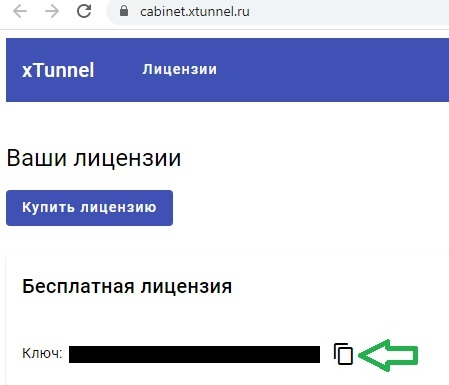

Нажмите на значок ключа (1) на левой панели меню коллаба, вставьте скопированный секретный ключ API в ячейку (4), впишите название ключа XTUNNEL_API_KEY в ячейку (3) и разрешите доступ к этому ключу (2)

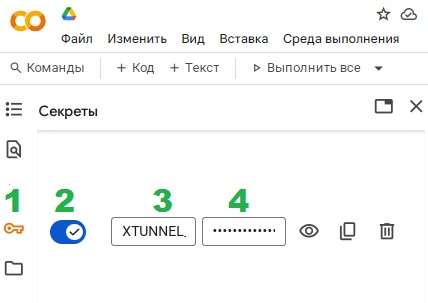

In [ ]:
%%writefile app.py
from typing import Any, Dict
from fastapi import FastAPI, responses, HTTPException
from pydantic import BaseModel
from scalar_doc import ScalarConfiguration, ScalarDoc
import nest_asyncio

nest_asyncio.apply()

DESCRIPTION = """
# Автодокументация

## Раздел

### Автодокументация

Описание сервера
"""

app = FastAPI(title="Test", description=DESCRIPTION, docs_url=None, redoc_url=None)
docs = ScalarDoc.from_spec(spec=app.openapi_url, mode="url")

# Аналог in-memory items_db из SimpleCRUDHandler
items_db: Dict[int, Dict[str, Any]] = {}
class ItemPayload(BaseModel):
    data: Dict[str, Any]

@app.get("/items")
def get_items():
    return dict(items_db.items())

@app.get("/items/{item_id}")
def get_item(item_id: int):
    if item_id not in items_db:
        raise HTTPException(status_code=404, detail="Item not found")
    return items_db[item_id]

@app.post("/items/new", status_code=201)
def create_item(payload: ItemPayload):
    # В SimpleCRUDHandler id = len(items_db) + 1
    item_id = len(items_db) + 1
    items_db[item_id] = payload.data
    return {"id": item_id}


@app.get("/docs", include_in_schema=False)
def get_docs():
    return responses.HTMLResponse(docs.to_html())

@app.get("/docs2", include_in_schema=False)
def get_docs2():
    docs2 = ScalarDoc.from_spec("http://127.0.0.1:8002/openapi.json", mode="url")
    docs2.set_title("Автодокументация")
    docs2.set_configuration(ScalarConfiguration())
    return responses.HTMLResponse(docs2.to_html())

Запускаю и проверяю локально, не через колаб.

In [ ]:
# !uvicorn app:app --host 127.0.0.1 --port 8002

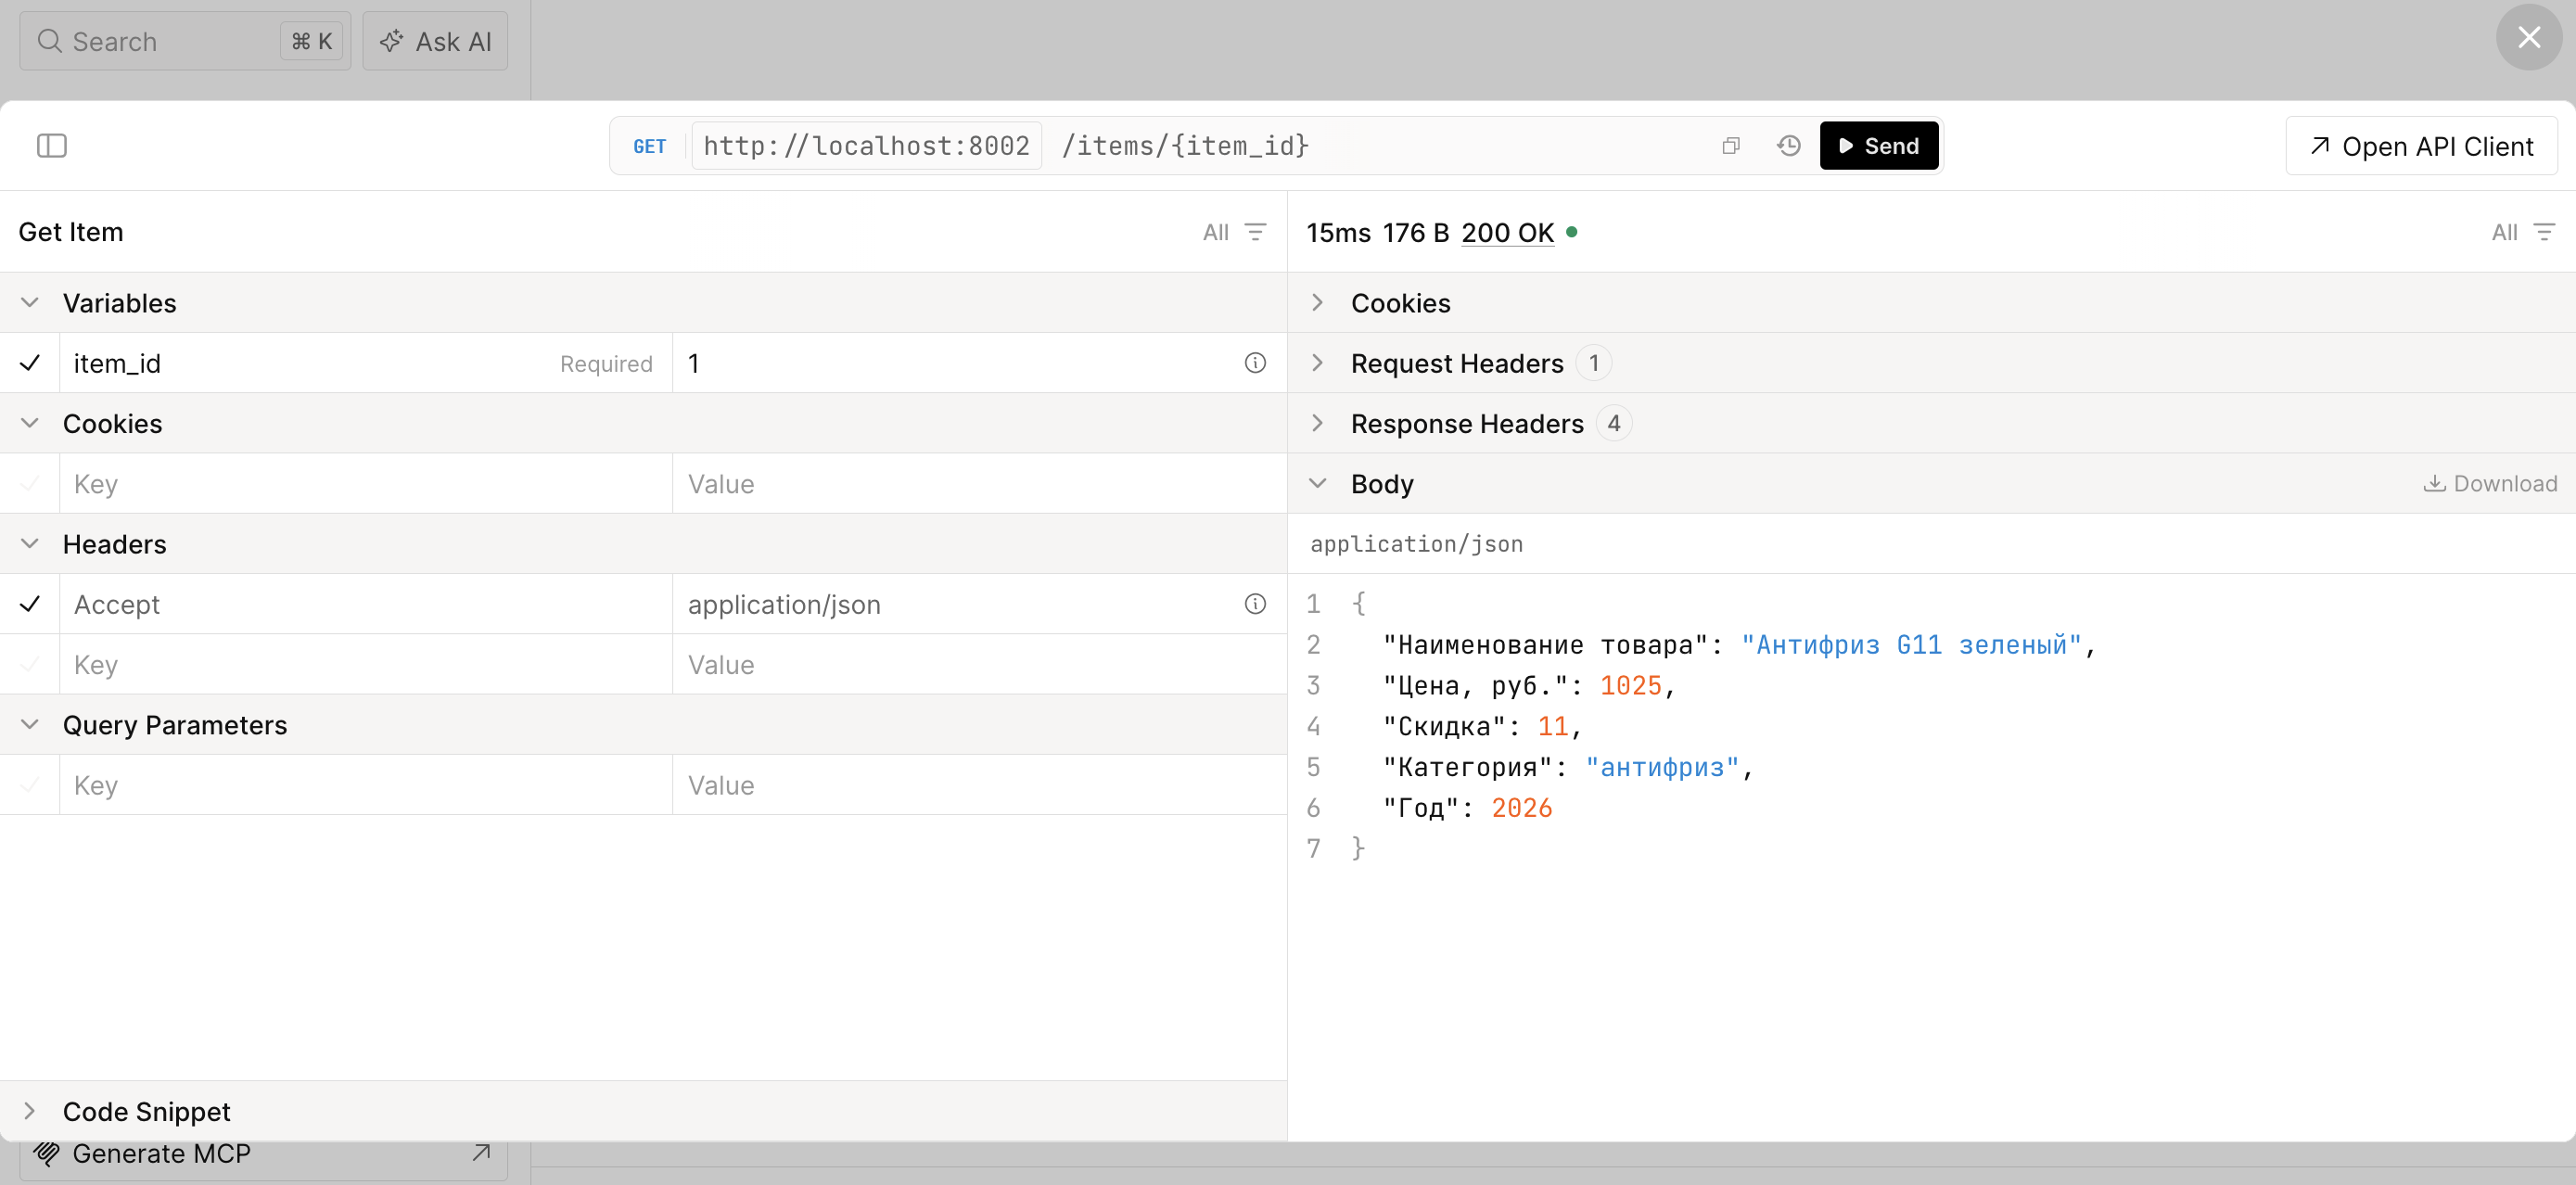

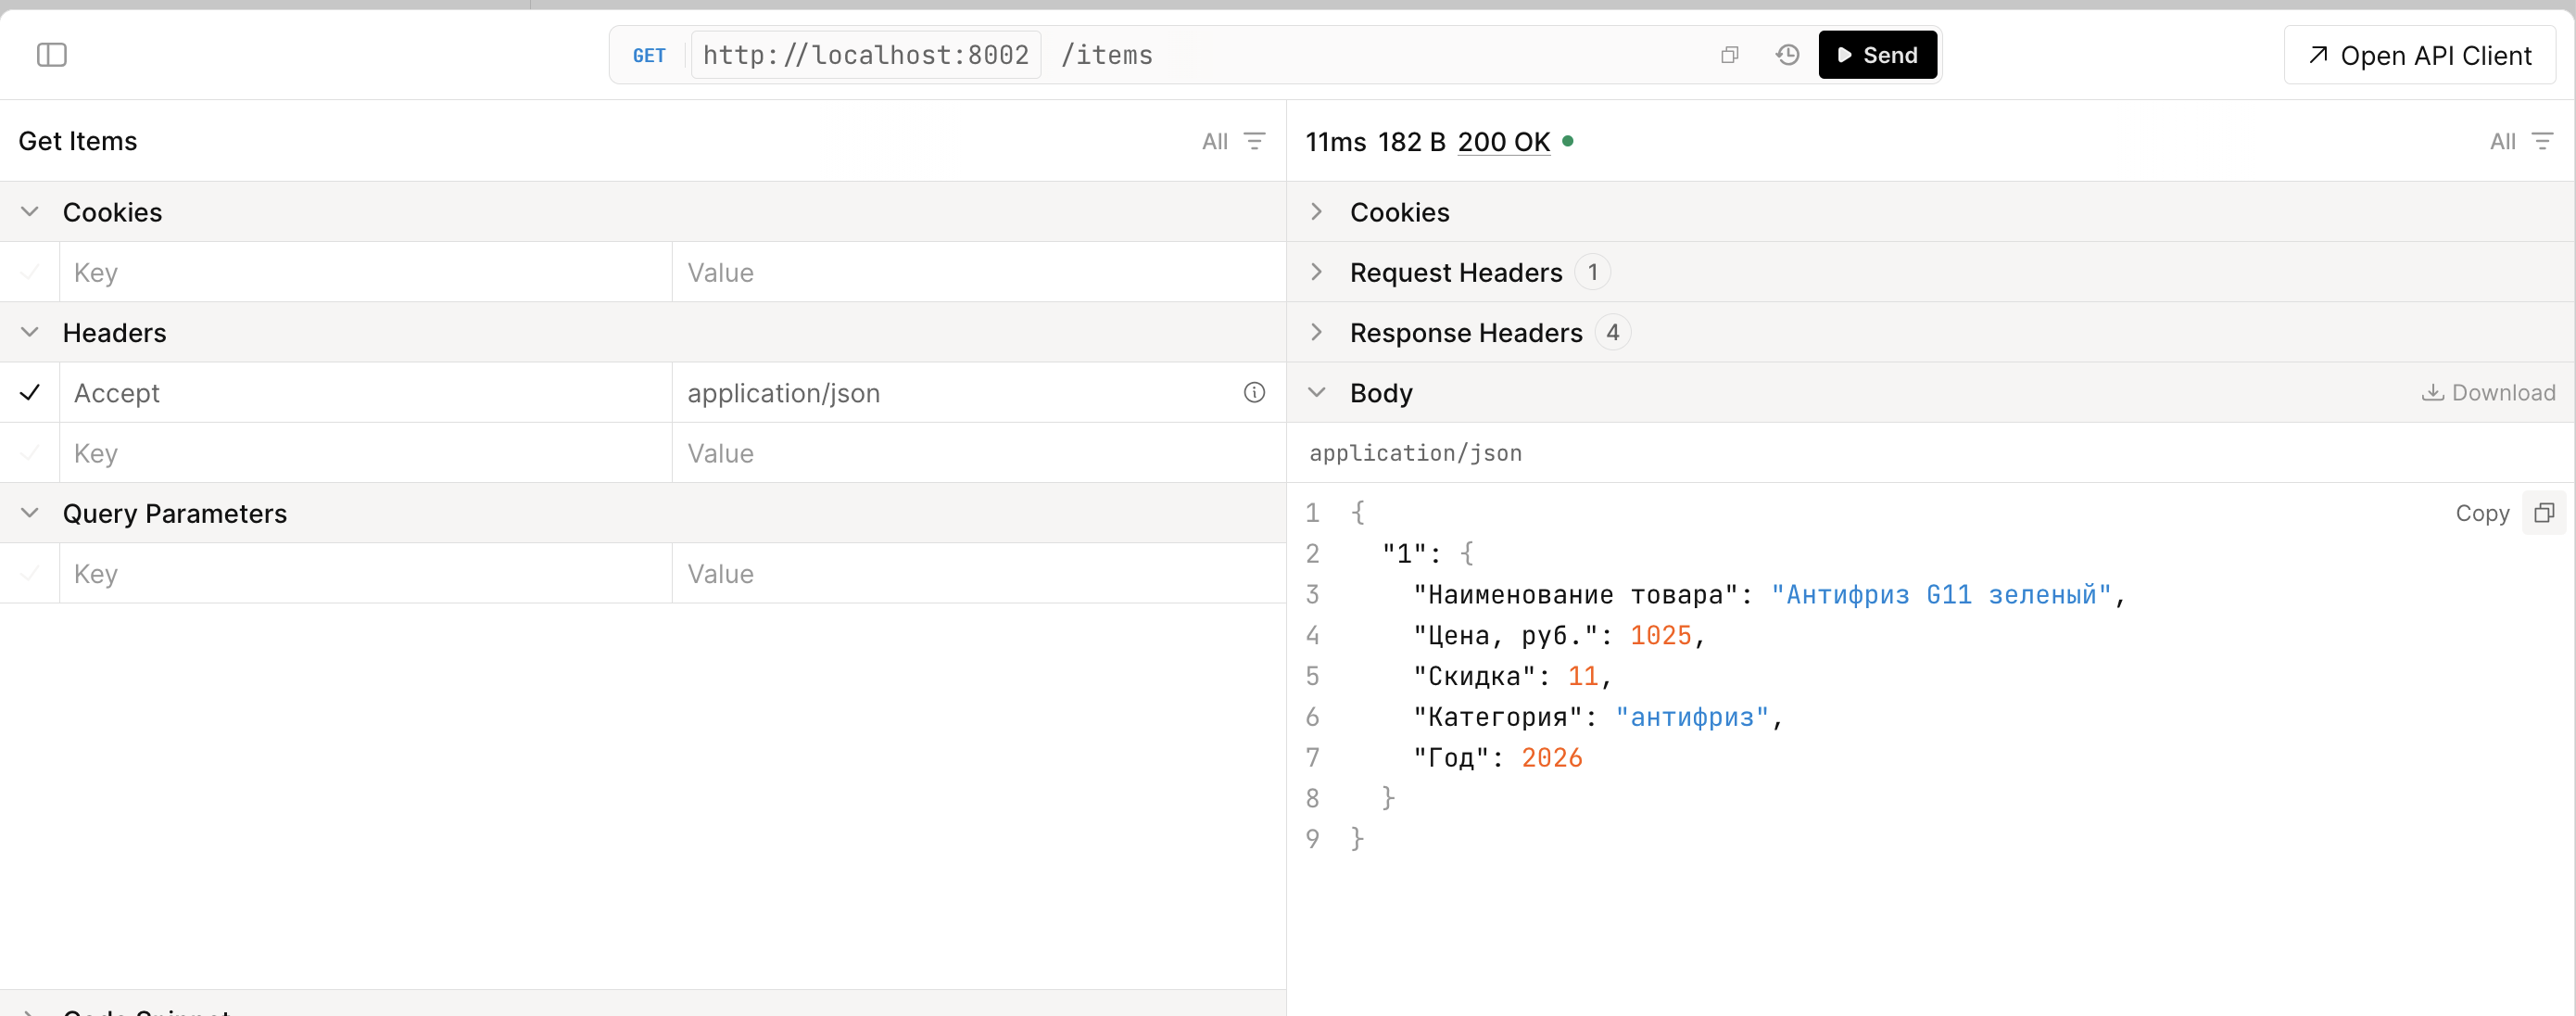

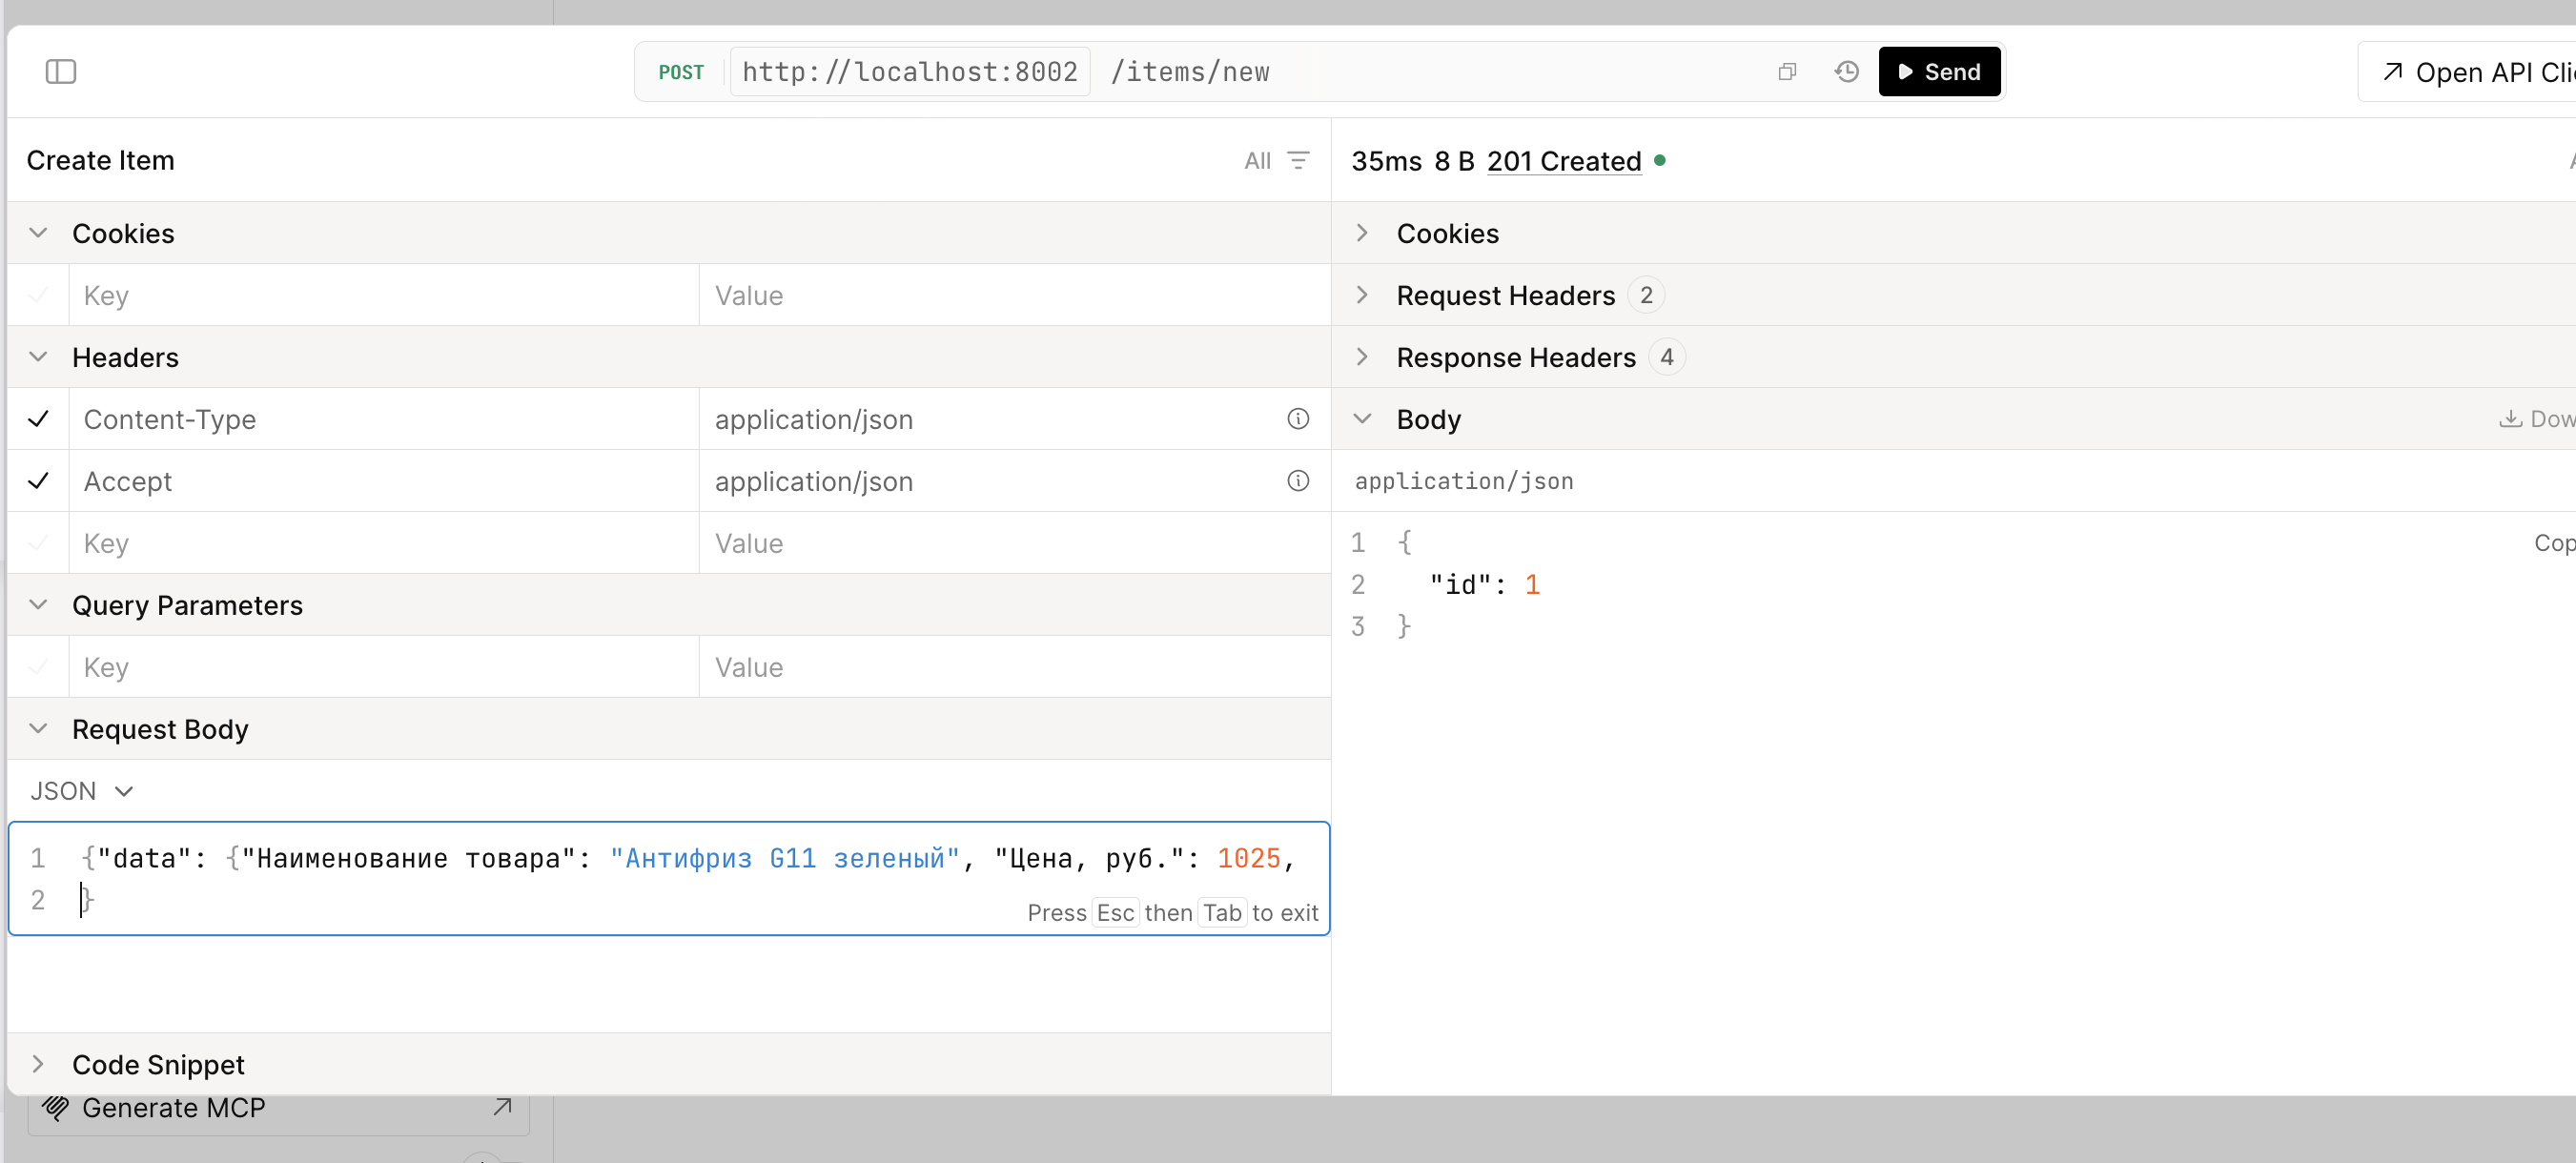

<!-- %%html
Сразу тестируйте свой код

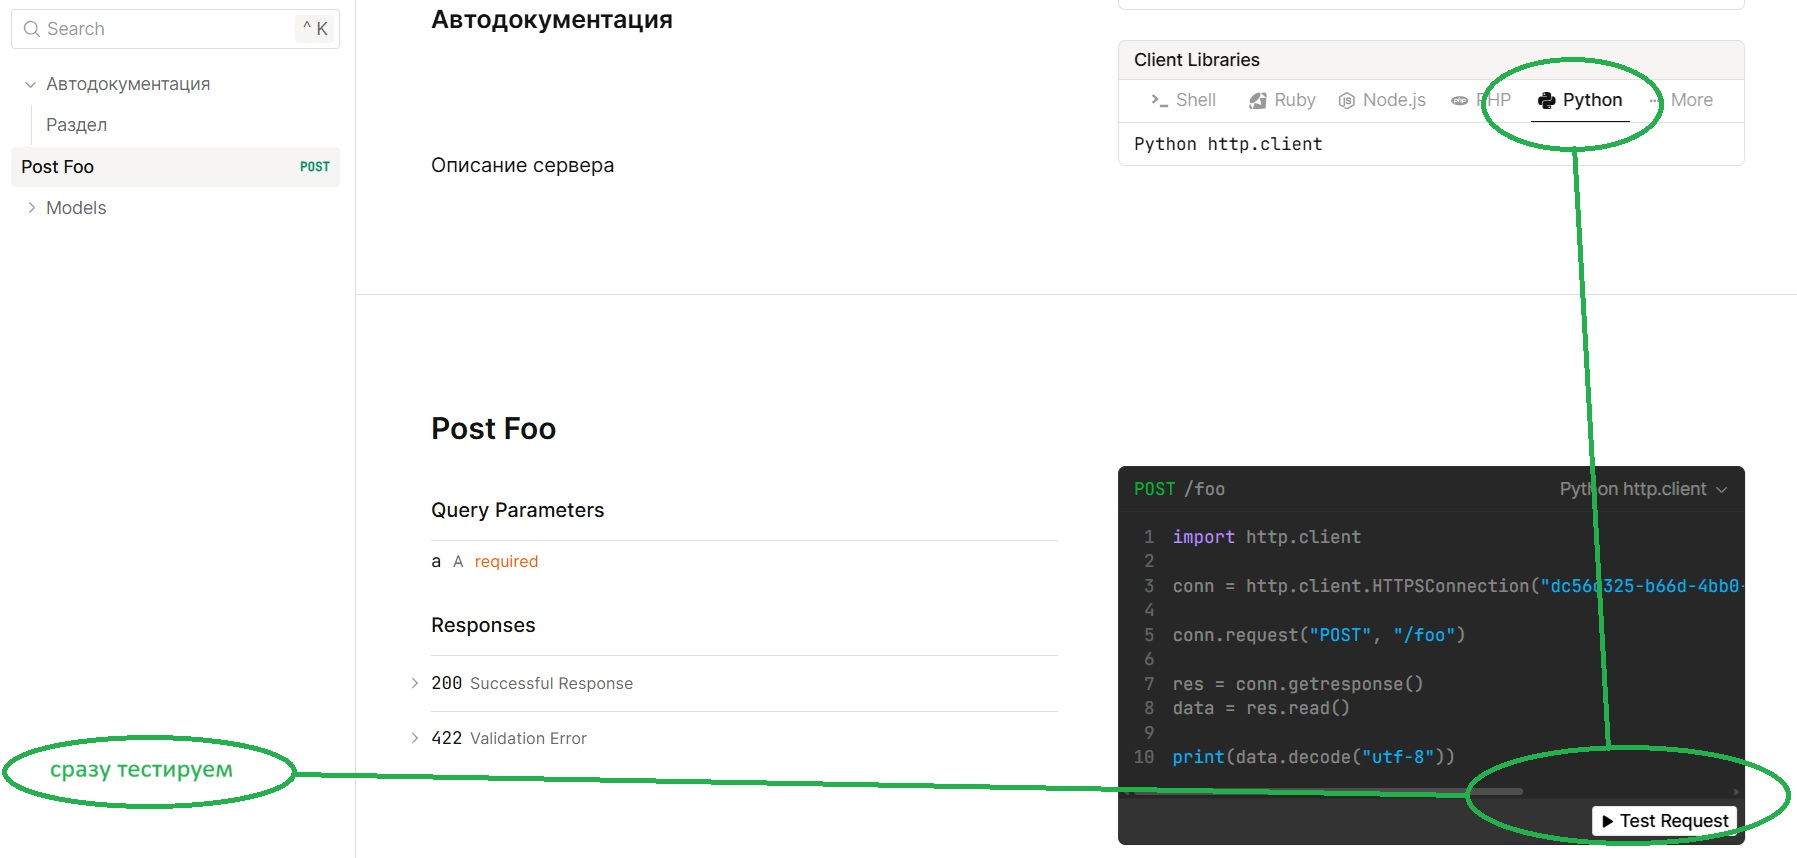 -->

%%html
Сразу тестируйте свой код

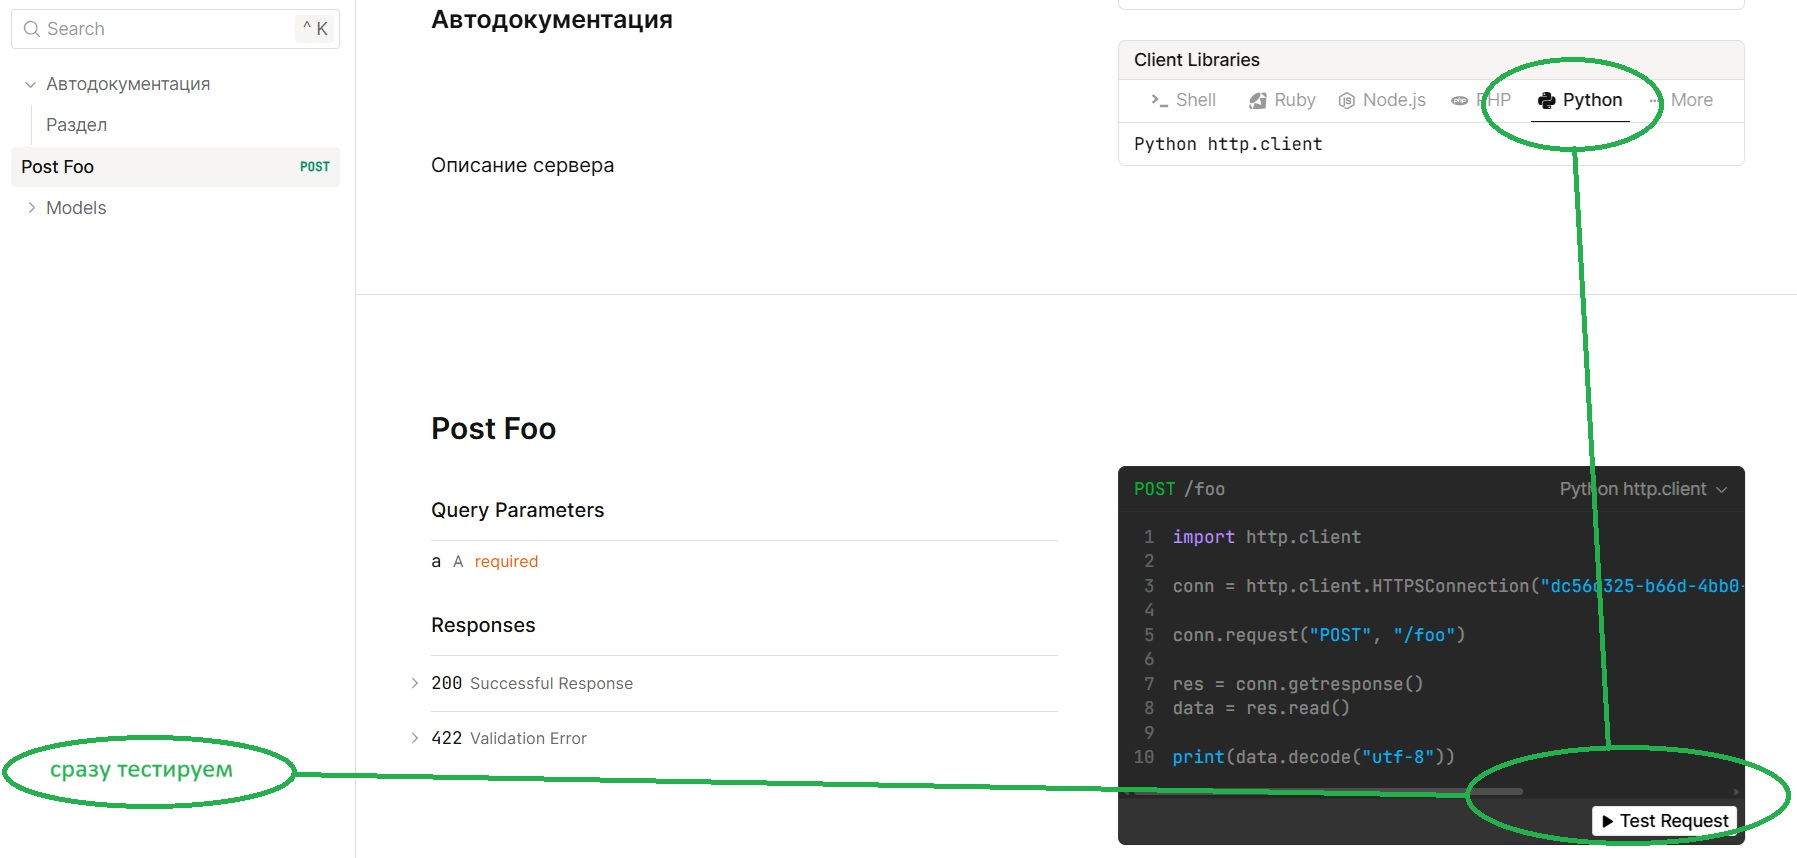

## Итоговое оформление


1. Проверьте, что ноутбук запускается.  
2. Сформулируйте ниже 5–8 выводов, когда стоит применять подход code-first и почему чаще стоит придерживаться подхода API-first.  



Когда стоит применять подход code-first:
- проект небольшой, например, студенческий
- сроки разработки сжаты
- количество разработчиков небольшое, например 1-4
- скорость разработки важнее чем качество, например, важнее проверить гипотезы, чем сделать очень качественный продукт, который возможно никому не нужен.

Когда стоит применять API-first:
- есть интеграции с другими внешними или внутренними сервисами и важно качество этих интеграций
- важна предсазуемость изменений
- в проекте несолько команд
- есть публичное апи

Чаще стоит придерживаться API-first так как предварительное согласование контратов снимает множество вопросов, конфликтов и противоречий в дальнейшем процессе разработки/доработки/интеграции и жизни проекта. 

## Примечание

Сохраните код работоспособного сервера из [ячейки](#scrollTo=EQRTmZPa2hi1).

Этот сервис пригодится для создания контейнеризированного приложения в ДЗ 4.